In [1]:
from modules.simple_training import TrainingConfig, train_validate_test

data_path = "./data/data_scaled.csv"

config = TrainingConfig(
    hidden_sizes=[128, 64],
    hidden_activation="relu",
    output_activation="linear",
    loss_name="mse",
    learning_rate=0.003,
    epochs=800,
    batch_size=16,
    test_size=0.2,
    val_size=0.2,
    random_state=67,
)

model, history, metrics, classes = train_validate_test(data_path, config)

print("\n==================== CLASSES ====================")
print(classes)

print("\n==================== TRAIN HISTORY ====================")
print("Final train loss:", history["train_loss"][-1])
print("Final val loss:", history["val_loss"][-1])
print("Best val loss:", min(history["val_loss"]))

print("\n==================== CLASSIFICATION METRICS ====================")
print(metrics)   # <-- TO DAJE accuracy, precision, recall, f1, confusion matrix


==================== CLASSES ====================
[0. 1. 2. 3. 4. 5.]

==================== TRAIN HISTORY ====================
Final train loss: 0.11369858999738693
Final val loss: 0.13285643924283
Best val loss: 0.13222764330439957

==================== CLASSIFICATION METRICS ====================
Accuracy:  0.4608
Precision: 0.2745
Recall:    0.2436
F1-score:  0.2549
Confusion matrix:
[[ 0  0  0  1  0  0]
 [ 1  1  4  4  0  0]
 [ 4  0 45 21  4  1]
 [ 4  4 30 40  4  4]
 [ 1  1  3 13  8  1]
 [ 0  0  1  2  2  0]]


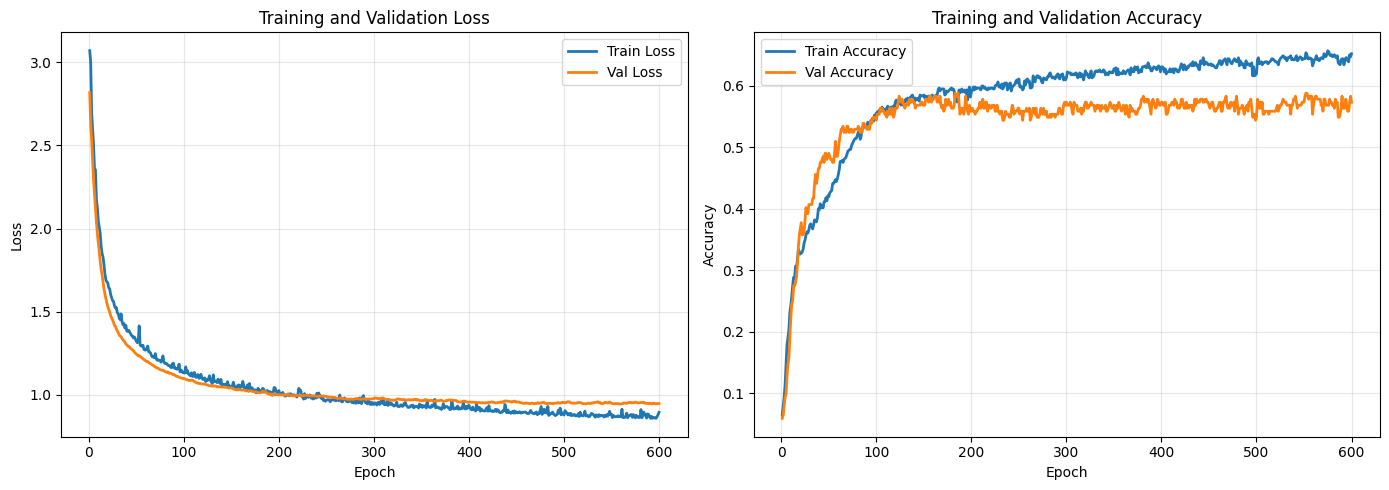

Best val loss: 0.944987 at epoch 559
Best val accuracy: 58.82% at epoch 183


In [27]:
import matplotlib.pyplot as plt
import numpy as np
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
epochs_range = range(1, len(history["train_loss"]) + 1)
ax1.plot(epochs_range, history["train_loss"], label="Train Loss", linewidth=2)
ax1.plot(epochs_range, history["val_loss"], label="Val Loss", linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training and Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(epochs_range, history["train_accuracy"], label="Train Accuracy", linewidth=2)
ax2.plot(epochs_range, history["val_accuracy"], label="Val Accuracy", linewidth=2)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Training and Validation Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best val loss: {min(history['val_loss']):.6f} at epoch {np.argmin(history['val_loss']) + 1}")
print(f"Best val accuracy: {max(history['val_accuracy']):.2%} at epoch {np.argmax(history['val_accuracy']) + 1}")


In [7]:
from modules.simple_training import train_validate_test, TrainingConfig
from modules.exmerimemt_manager import ExperimentManager
def run_all_experiments(data_path):
    manager = ExperimentManager()

    current_best_config = TrainingConfig(
        hidden_sizes=[128, 64],
        hidden_activation="relu",
        output_activation="linear",
        loss_name="cross_entropy",
        learning_rate=0.003,
        epochs=800,
        batch_size=16,
        test_size=0.2,
        val_size=0.2,
        random_state=67,
    )

    # 1. Eksperyment: Liczba warstw (2-5)
    print("--- Testowanie liczby warstw ---")
    for n_layers in range(2, 6):
        current_best_config.hidden_sizes = [64] * n_layers
        _, hist, met, _ = train_validate_test(data_path, current_best_config)
        manager.add_result(current_best_config, met, hist)

    best_layers_str = manager.get_best_param("hidden_sizes")
    current_best_config.hidden_sizes = eval(best_layers_str)

    # 2. Eksperyment: Liczba neuronów (16-256, co 3)
    print("--- Testowanie liczby neuronów ---")
    for n_neurons in range(2,65, 2):
        current_best_config.hidden_sizes = [n_neurons] * len(current_best_config.hidden_sizes)
        _, hist, met, _ = train_validate_test(data_path, current_best_config)
        manager.add_result(current_best_config, met, hist)

    best_n = eval(manager.get_best_param("hidden_sizes"))[0]
    current_best_config.hidden_sizes = [best_n] * len(current_best_config.hidden_sizes)

    # 3. Eksperyment: Funkcje aktywacji
    print("--- Testowanie aktywacji ---")
    for act in ["relu", "sigmoid", "tanh"]:
        current_best_config.hidden_activation = act
        _, hist, met, _ = train_validate_test(data_path, current_best_config)
        manager.add_result(current_best_config, met, hist)

    current_best_config.hidden_activation = manager.get_best_param("hidden_activation")

    # 4. Eksperyment: Funkcje straty
    print("--- Testowanie funkcji straty ---")
    for loss in ["cross_entropy", "mse"]:
        current_best_config.loss_name = loss
        _, hist, met, _ = train_validate_test(data_path, current_best_config)
        manager.add_result(current_best_config, met, hist)

    current_best_config.loss_name = manager.get_best_param("loss_name")

    # 5. Eksperyment: Współczynnik uczenia
    print("--- Testowanie Learning Rate ---")
    for lr in [x/1000 for x in range(1, 11)]:
        current_best_config.learning_rate = lr
        _, hist, met, _ = train_validate_test(data_path, current_best_config)
        manager.add_result(current_best_config, met, hist)

    current_best_config.learning_rate = manager.get_best_param("learning_rate")

    # 6. Eksperyment: Liczba epok (50-3000, co 50)
    print("--- Testowanie liczby epok ---")
    for ep in range(50, 3001, 50):
        current_best_config.epochs = ep
        _, hist, met, _ = train_validate_test(data_path, current_best_config)
        manager.add_result(current_best_config, met, hist)

    current_best_config.epochs = manager.get_best_param("epochs")

    # 7. Eksperyment: Batch size (1-100, co 2)
    print("--- Testowanie Batch Size ---")
    for bs in range(1, 101, 2):
        current_best_config.batch_size = bs
        _, hist, met, _ = train_validate_test(data_path, current_best_config)
        manager.add_result(current_best_config, met, hist)
    butterfly_architectures = [
        [64, 32, 64],
        [64, 16, 64],
        [48, 24, 48],
        [32, 64, 32],
        [64, 32, 16, 32, 64]
    ]

    print("--- Testowanie architektur typu Butterfly ---")
    for arch in butterfly_architectures:
        config.hidden_sizes = arch
        model, hist, met, _ = train_validate_test(data_path, config)
        manager.add_result(config, met, hist)



    print("\nEKSPERYMENTY ZAKOŃCZONE\n")
    print(manager.to_markdown())

In [8]:
run_all_experiments("./data/data_scaled.csv")

--- Testowanie liczby warstw ---
--- Testowanie liczby neuronów ---
--- Testowanie aktywacji ---
--- Testowanie funkcji straty ---
--- Testowanie Learning Rate ---
--- Testowanie liczby epok ---
--- Testowanie Batch Size ---
--- Testowanie architektur typu Butterfly ---

EKSPERYMENTY ZAKOŃCZONE

| hidden_sizes         | hidden_activation   | loss_name     |   learning_rate |   epochs |   batch_size |   accuracy |        f1 |   final_loss |
|:---------------------|:--------------------|:--------------|----------------:|---------:|-------------:|-----------:|----------:|-------------:|
| [64, 64]             | relu                | cross_entropy |           0.003 |      800 |           16 |   0.593137 | 0.264213  |     0.925833 |
| [64, 64, 64]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.588235 | 0.277447  |     0.889104 |
| [64, 64, 64, 64]     | relu                | cross_entropy |           0.003 |      800 |           16 |   0.5735

| hidden_sizes         | hidden_activation   | loss_name     |   learning_rate |   epochs |   batch_size |   accuracy |       f1 |   final_loss |
|:---------------------|:--------------------|:--------------|----------------:|---------:|-------------:|-----------:|---------:|-------------:|
| [64, 64]             | relu                | cross_entropy |           0.003 |      800 |           16 |   0.588235 | 0.27421  |     0.923488 |
| [64, 64, 64]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.593137 | 0.275659 |     0.934455 |
| [64, 64, 64, 64]     | relu                | cross_entropy |           0.003 |      800 |           16 |   0.568627 | 0.27307  |     0.899731 |
| [64, 64, 64, 64, 64] | relu                | cross_entropy |           0.003 |      800 |           16 |   0.568627 | 0.25525  |     0.933592 |
| [16, 16, 16]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.553922 | 0.248143 |     0.944422 |
| [19, 19, 19]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.553922 | 0.226433 |     0.956931 |
| [22, 22, 22]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.54902  | 0.215405 |     0.979059 |
| [25, 25, 25]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.593137 | 0.276649 |     0.970494 |
| [28, 28, 28]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.544118 | 0.262205 |     0.921223 |
| [31, 31, 31]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.519608 | 0.221444 |     0.993536 |
| [34, 34, 34]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.568627 | 0.283875 |     0.921851 |
| [37, 37, 37]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.588235 | 0.288035 |     0.94746  |
| [40, 40, 40]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.54902  | 0.263242 |     0.976509 |
| [43, 43, 43]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.558824 | 0.248457 |     0.915079 |
| [46, 46, 46]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.558824 | 0.25967  |     0.948923 |
| [49, 49, 49]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.583333 | 0.261166 |     0.934203 |
| [52, 52, 52]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.583333 | 0.276727 |     0.944845 |
| [55, 55, 55]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.563725 | 0.273657 |     0.913836 |
| [58, 58, 58]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.573529 | 0.262537 |     0.931616 |
| [61, 61, 61]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.558824 | 0.266968 |     0.952294 |
| [64, 64, 64]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.553922 | 0.254936 |     0.900146 |
| [67, 67, 67]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.588235 | 0.269684 |     0.922841 |
| [70, 70, 70]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.539216 | 0.236019 |     0.937708 |
| [73, 73, 73]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.583333 | 0.285428 |     0.920563 |
| [76, 76, 76]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.563725 | 0.276039 |     0.926496 |
| [79, 79, 79]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.573529 | 0.270477 |     0.94746  |
| [82, 82, 82]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.573529 | 0.25807  |     0.937339 |
| [85, 85, 85]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.539216 | 0.235187 |     0.940024 |
| [88, 88, 88]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.553922 | 0.261801 |     0.929081 |
| [91, 91, 91]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.553922 | 0.266844 |     0.918307 |
| [94, 94, 94]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.578431 | 0.276709 |     0.899037 |
| [97, 97, 97]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.558824 | 0.263128 |     0.906486 |
| [100, 100, 100]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.558824 | 0.261691 |     0.926603 |
| [103, 103, 103]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.563725 | 0.266588 |     0.890243 |
| [106, 106, 106]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.583333 | 0.282954 |     0.904783 |
| [109, 109, 109]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.553922 | 0.247609 |     0.940788 |
| [112, 112, 112]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.588235 | 0.29006  |     0.947506 |
| [115, 115, 115]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.54902  | 0.275095 |     0.941798 |
| [118, 118, 118]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.598039 | 0.287336 |     0.914882 |
| [121, 121, 121]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.573529 | 0.279512 |     0.922193 |
| [124, 124, 124]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.583333 | 0.275257 |     0.919023 |
| [127, 127, 127]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.568627 | 0.263585 |     0.974638 |
| [130, 130, 130]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.553922 | 0.249374 |     0.921927 |
| [133, 133, 133]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.568627 | 0.259911 |     0.896088 |
| [136, 136, 136]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.558824 | 0.267418 |     0.905641 |
| [139, 139, 139]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.588235 | 0.275308 |     0.927481 |
| [142, 142, 142]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.563725 | 0.281221 |     0.909902 |
| [145, 145, 145]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.593137 | 0.276477 |     0.903582 |
| [148, 148, 148]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.563725 | 0.272486 |     0.884186 |
| [151, 151, 151]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.593137 | 0.282144 |     0.92648  |
| [154, 154, 154]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.553922 | 0.265076 |     0.937803 |
| [157, 157, 157]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.578431 | 0.283218 |     0.93473  |
| [160, 160, 160]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.583333 | 0.294528 |     0.956771 |
| [163, 163, 163]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.588235 | 0.288394 |     0.955655 |
| [166, 166, 166]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.583333 | 0.260454 |     0.947973 |
| [169, 169, 169]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.593137 | 0.282957 |     0.892481 |
| [172, 172, 172]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.598039 | 0.29511  |     0.915637 |
| [175, 175, 175]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.578431 | 0.295655 |     0.934991 |
| [178, 178, 178]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.568627 | 0.277761 |     0.926337 |
| [181, 181, 181]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.54902  | 0.265251 |     0.893039 |
| [184, 184, 184]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.578431 | 0.277346 |     0.942426 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.588235 | 0.299655 |     0.927445 |
| [190, 190, 190]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.563725 | 0.263157 |     0.941752 |
| [193, 193, 193]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.578431 | 0.27487  |     0.950027 |
| [196, 196, 196]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.558824 | 0.261639 |     0.901869 |
| [199, 199, 199]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.534314 | 0.257494 |     0.910735 |
| [202, 202, 202]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.568627 | 0.267979 |     0.963943 |
| [205, 205, 205]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.568627 | 0.265233 |     0.940937 |
| [208, 208, 208]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.558824 | 0.276753 |     0.919957 |
| [211, 211, 211]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.598039 | 0.282213 |     0.961195 |
| [214, 214, 214]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.504902 | 0.23514  |     0.911187 |
| [217, 217, 217]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.563725 | 0.278132 |     0.968444 |
| [220, 220, 220]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.573529 | 0.261567 |     0.962254 |
| [223, 223, 223]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.583333 | 0.297912 |     0.97833  |
| [226, 226, 226]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.578431 | 0.26852  |     0.932144 |
| [229, 229, 229]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.573529 | 0.277154 |     0.899637 |
| [232, 232, 232]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.578431 | 0.272409 |     0.930907 |
| [235, 235, 235]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.563725 | 0.275627 |     0.915987 |
| [238, 238, 238]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.568627 | 0.281731 |     0.903644 |
| [241, 241, 241]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.568627 | 0.265498 |     0.903081 |
| [244, 244, 244]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.568627 | 0.288053 |     0.897392 |
| [247, 247, 247]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.558824 | 0.266479 |     0.926632 |
| [250, 250, 250]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.544118 | 0.26477  |     0.941877 |
| [253, 253, 253]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.568627 | 0.277885 |     0.933069 |
| [256, 256, 256]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.563725 | 0.277872 |     0.919145 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.578431 | 0.280403 |     0.923947 |
| [187, 187, 187]      | sigmoid             | cross_entropy |           0.003 |      800 |           16 |   0.529412 | 0.198186 |     1.073    |
| [187, 187, 187]      | tanh                | cross_entropy |           0.003 |      800 |           16 |   0.578431 | 0.281054 |     0.928216 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.568627 | 0.27159  |     0.921222 |
| [187, 187, 187]      | relu                | mse           |           0.003 |      800 |           16 |   0.509804 | 0.246053 |     0.130556 |
| [187, 187, 187]      | relu                | cross_entropy |           0.001 |      800 |           16 |   0.573529 | 0.276504 |     0.950555 |
| [187, 187, 187]      | relu                | cross_entropy |           0.002 |      800 |           16 |   0.593137 | 0.292788 |     0.949976 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.583333 | 0.313356 |     0.935019 |
| [187, 187, 187]      | relu                | cross_entropy |           0.004 |      800 |           16 |   0.612745 | 0.289453 |     0.986491 |
| [187, 187, 187]      | relu                | cross_entropy |           0.005 |      800 |           16 |   0.553922 | 0.276755 |     0.953461 |
| [187, 187, 187]      | relu                | cross_entropy |           0.006 |      800 |           16 |   0.573529 | 0.257541 |     1.1158   |
| [187, 187, 187]      | relu                | cross_entropy |           0.007 |      800 |           16 |   0.563725 | 0.274147 |     1.00262  |
| [187, 187, 187]      | relu                | cross_entropy |           0.008 |      800 |           16 |   0.563725 | 0.272321 |     1.02867  |
| [187, 187, 187]      | relu                | cross_entropy |           0.009 |      800 |           16 |   0.563725 | 0.255014 |     1.10833  |
| [187, 187, 187]      | relu                | cross_entropy |           0.01  |      800 |           16 |   0.504902 | 0.246092 |     1.1212   |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |       50 |           16 |   0.519608 | 0.236552 |     1.03509  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      100 |           16 |   0.544118 | 0.224394 |     1.07757  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      150 |           16 |   0.514706 | 0.225348 |     0.97251  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      200 |           16 |   0.568627 | 0.275997 |     0.901997 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      250 |           16 |   0.553922 | 0.267121 |     0.966833 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      300 |           16 |   0.602941 | 0.28192  |     0.962405 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      350 |           16 |   0.573529 | 0.284177 |     0.895001 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      400 |           16 |   0.553922 | 0.261356 |     0.897925 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      450 |           16 |   0.544118 | 0.250977 |     0.948295 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      500 |           16 |   0.568627 | 0.269486 |     0.958564 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      550 |           16 |   0.583333 | 0.274623 |     0.912387 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      600 |           16 |   0.578431 | 0.294677 |     0.963314 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      650 |           16 |   0.588235 | 0.287635 |     0.921347 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           16 |   0.593137 | 0.330529 |     0.985967 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      750 |           16 |   0.539216 | 0.284631 |     0.95521  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      800 |           16 |   0.578431 | 0.27051  |     0.936157 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      850 |           16 |   0.593137 | 0.266001 |     0.947184 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      900 |           16 |   0.583333 | 0.281697 |     0.928979 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      950 |           16 |   0.607843 | 0.293365 |     0.94917  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     1000 |           16 |   0.539216 | 0.252275 |     0.908965 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     1050 |           16 |   0.544118 | 0.259683 |     0.940396 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     1100 |           16 |   0.583333 | 0.274041 |     0.94391  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     1150 |           16 |   0.534314 | 0.253852 |     0.945769 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     1200 |           16 |   0.573529 | 0.274015 |     0.990895 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     1250 |           16 |   0.539216 | 0.242805 |     0.947247 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     1300 |           16 |   0.558824 | 0.274997 |     0.924284 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     1350 |           16 |   0.583333 | 0.276534 |     0.91884  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     1400 |           16 |   0.583333 | 0.285024 |     1.01717  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     1450 |           16 |   0.54902  | 0.272058 |     0.973916 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     1500 |           16 |   0.602941 | 0.29182  |     0.981742 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     1550 |           16 |   0.563725 | 0.279068 |     0.990099 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     1600 |           16 |   0.583333 | 0.255636 |     0.984881 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     1650 |           16 |   0.558824 | 0.268849 |     1.00047  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     1700 |           16 |   0.52451  | 0.252236 |     0.981442 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     1750 |           16 |   0.544118 | 0.253739 |     1.02354  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     1800 |           16 |   0.563725 | 0.272016 |     1.00076  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     1850 |           16 |   0.52451  | 0.248706 |     0.999301 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     1900 |           16 |   0.602941 | 0.300448 |     1.02938  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     1950 |           16 |   0.558824 | 0.253459 |     1.02203  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     2000 |           16 |   0.534314 | 0.262999 |     0.989208 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     2050 |           16 |   0.578431 | 0.280379 |     1.05332  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     2100 |           16 |   0.583333 | 0.291802 |     1.05581  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     2150 |           16 |   0.558824 | 0.262539 |     1.03988  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     2200 |           16 |   0.534314 | 0.265324 |     1.06915  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     2250 |           16 |   0.529412 | 0.257407 |     1.02657  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     2300 |           16 |   0.54902  | 0.268999 |     1.05633  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     2350 |           16 |   0.563725 | 0.297367 |     1.05388  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     2400 |           16 |   0.583333 | 0.278395 |     1.07847  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     2450 |           16 |   0.529412 | 0.245376 |     1.08699  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     2500 |           16 |   0.553922 | 0.280315 |     1.07061  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     2550 |           16 |   0.519608 | 0.258752 |     1.12022  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     2600 |           16 |   0.558824 | 0.268981 |     1.05079  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     2650 |           16 |   0.593137 | 0.280444 |     1.11221  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     2700 |           16 |   0.563725 | 0.27848  |     1.09257  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     2750 |           16 |   0.553922 | 0.276215 |     1.08388  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     2800 |           16 |   0.514706 | 0.255007 |     1.12666  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     2850 |           16 |   0.578431 | 0.292009 |     1.07801  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     2900 |           16 |   0.534314 | 0.256438 |     1.07486  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     2950 |           16 |   0.54902  | 0.259139 |     1.10989  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     3000 |           16 |   0.558824 | 0.302856 |     1.17151  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     3050 |           16 |   0.544118 | 0.256638 |     1.24106  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     3100 |           16 |   0.573529 | 0.274207 |     1.2304   |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     3150 |           16 |   0.529412 | 0.265475 |     1.13692  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     3200 |           16 |   0.558824 | 0.272424 |     1.1614   |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     3250 |           16 |   0.529412 | 0.24617  |     1.24945  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     3300 |           16 |   0.568627 | 0.268261 |     1.14624  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     3350 |           16 |   0.553922 | 0.263101 |     1.12916  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     3400 |           16 |   0.509804 | 0.242325 |     1.27302  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     3450 |           16 |   0.529412 | 0.250826 |     1.11651  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     3500 |           16 |   0.514706 | 0.243849 |     1.2966   |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     3550 |           16 |   0.558824 | 0.29011  |     1.23189  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     3600 |           16 |   0.558824 | 0.262888 |     1.25565  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     3650 |           16 |   0.544118 | 0.251559 |     1.16588  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     3700 |           16 |   0.553922 | 0.271371 |     1.24067  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     3750 |           16 |   0.578431 | 0.265188 |     1.19574  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     3800 |           16 |   0.534314 | 0.271232 |     1.23705  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     3850 |           16 |   0.534314 | 0.267299 |     1.24937  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     3900 |           16 |   0.529412 | 0.256383 |     1.29131  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     3950 |           16 |   0.529412 | 0.241949 |     1.30749  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     4000 |           16 |   0.558824 | 0.260212 |     1.29039  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     4050 |           16 |   0.544118 | 0.264628 |     1.37016  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     4100 |           16 |   0.573529 | 0.266899 |     1.34104  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     4150 |           16 |   0.54902  | 0.301994 |     1.32281  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     4200 |           16 |   0.583333 | 0.309199 |     1.377    |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     4250 |           16 |   0.539216 | 0.242735 |     1.28467  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     4300 |           16 |   0.514706 | 0.239233 |     1.37301  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     4350 |           16 |   0.583333 | 0.286811 |     1.3038   |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     4400 |           16 |   0.52451  | 0.249969 |     1.38491  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     4450 |           16 |   0.563725 | 0.271492 |     1.37052  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     4500 |           16 |   0.568627 | 0.281823 |     1.23449  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     4550 |           16 |   0.534314 | 0.257827 |     1.45364  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     4600 |           16 |   0.54902  | 0.292181 |     1.49105  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     4650 |           16 |   0.534314 | 0.256146 |     1.44511  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     4700 |           16 |   0.539216 | 0.262331 |     1.36296  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     4750 |           16 |   0.54902  | 0.262322 |     1.3911   |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     4800 |           16 |   0.563725 | 0.277967 |     1.37654  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     4850 |           16 |   0.573529 | 0.298826 |     1.36585  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     4900 |           16 |   0.534314 | 0.245527 |     1.43117  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     4950 |           16 |   0.583333 | 0.285662 |     1.27954  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |     5000 |           16 |   0.514706 | 0.249729 |     1.384    |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |            1 |   0.544118 | 0.26847  |     3.1235   |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |            3 |   0.563725 | 0.276236 |     2.07841  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |            5 |   0.573529 | 0.275962 |     1.74238  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |            7 |   0.534314 | 0.253076 |     1.21012  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |            9 |   0.544118 | 0.259623 |     1.03539  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           11 |   0.578431 | 0.276952 |     0.960845 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           13 |   0.578431 | 0.271495 |     0.920971 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           15 |   0.553922 | 0.262004 |     0.929754 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           17 |   0.583333 | 0.273826 |     0.931162 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           19 |   0.583333 | 0.293181 |     0.954973 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           21 |   0.529412 | 0.23897  |     0.947432 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           23 |   0.553922 | 0.247731 |     0.94512  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           25 |   0.602941 | 0.283816 |     0.919749 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           27 |   0.578431 | 0.281725 |     0.943196 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           29 |   0.54902  | 0.254701 |     0.940695 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           31 |   0.558824 | 0.273609 |     0.933134 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           33 |   0.539216 | 0.246998 |     0.89313  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           35 |   0.588235 | 0.28044  |     0.925593 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           37 |   0.544118 | 0.256296 |     0.965895 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           39 |   0.588235 | 0.287247 |     0.945416 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           41 |   0.544118 | 0.265478 |     1.01587  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           43 |   0.529412 | 0.231514 |     0.966448 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           45 |   0.558824 | 0.265025 |     0.995786 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           47 |   0.568627 | 0.255238 |     1.04606  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           49 |   0.558824 | 0.256981 |     0.972917 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           51 |   0.529412 | 0.245853 |     1.01849  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           53 |   0.563725 | 0.26599  |     1.00791  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           55 |   0.573529 | 0.27294  |     0.94154  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           57 |   0.52451  | 0.222654 |     0.980236 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           59 |   0.568627 | 0.265549 |     0.982309 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           61 |   0.52451  | 0.230313 |     1.05425  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           63 |   0.529412 | 0.252177 |     1.01396  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           65 |   0.529412 | 0.232029 |     0.996388 |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           67 |   0.54902  | 0.265108 |     1.00294  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           69 |   0.52451  | 0.23141  |     1.08218  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           71 |   0.52451  | 0.230393 |     1.06481  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           73 |   0.544118 | 0.237555 |     1.04075  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           75 |   0.553922 | 0.234253 |     1.01838  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           77 |   0.519608 | 0.233413 |     1.06188  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           79 |   0.558824 | 0.250517 |     1.0468   |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           81 |   0.5      | 0.186685 |     1.07854  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           83 |   0.5      | 0.237303 |     1.10935  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           85 |   0.544118 | 0.258741 |     1.01225  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           87 |   0.568627 | 0.263    |     1.0551   |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           89 |   0.514706 | 0.236594 |     1.01302  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           91 |   0.544118 | 0.236965 |     1.0622   |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           93 |   0.52451  | 0.223573 |     1.09001  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           95 |   0.504902 | 0.208151 |     1.08377  |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           97 |   0.54902  | 0.224835 |     1.0969   |
| [187, 187, 187]      | relu                | cross_entropy |           0.003 |      700 |           99 |   0.544118 | 0.258875 |     1.04903  |


| hidden_sizes         | hidden_activation   | loss_name     |   learning_rate |   epochs |   batch_size |   accuracy |        f1 |   final_loss |
|:---------------------|:--------------------|:--------------|----------------:|---------:|-------------:|-----------:|----------:|-------------:|
| [64, 64]             | relu                | cross_entropy |           0.003 |      800 |           16 |   0.593137 | 0.264213  |     0.925833 |
| [64, 64, 64]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.588235 | 0.277447  |     0.889104 |
| [64, 64, 64, 64]     | relu                | cross_entropy |           0.003 |      800 |           16 |   0.573529 | 0.271358  |     0.959369 |
| [64, 64, 64, 64, 64] | relu                | cross_entropy |           0.003 |      800 |           16 |   0.588235 | 0.274484  |     0.98903  |
| [2, 2, 2]            | relu                | cross_entropy |           0.003 |      800 |           16 |   0.367647 | 0.0896057 |     1.24899  |
| [4, 4, 4]            | relu                | cross_entropy |           0.003 |      800 |           16 |   0.470588 | 0.172951  |     1.10883  |
| [6, 6, 6]            | relu                | cross_entropy |           0.003 |      800 |           16 |   0.504902 | 0.186917  |     1.03399  |
| [8, 8, 8]            | relu                | cross_entropy |           0.003 |      800 |           16 |   0.509804 | 0.198473  |     0.980898 |
| [10, 10, 10]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.504902 | 0.208352  |     1.01271  |
| [12, 12, 12]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.544118 | 0.203297  |     1.00599  |
| [14, 14, 14]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.5      | 0.223678  |     0.993401 |
| [16, 16, 16]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.568627 | 0.263129  |     0.953427 |
| [18, 18, 18]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.563725 | 0.26335   |     0.967262 |
| [20, 20, 20]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.534314 | 0.209792  |     1.02478  |
| [22, 22, 22]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.529412 | 0.22571   |     0.978876 |
| [24, 24, 24]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.54902  | 0.262994  |     0.944177 |
| [26, 26, 26]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.568627 | 0.261462  |     0.956067 |
| [28, 28, 28]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.578431 | 0.227791  |     0.957074 |
| [30, 30, 30]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.54902  | 0.23296   |     0.945011 |
| [32, 32, 32]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.534314 | 0.239843  |     0.955636 |
| [34, 34, 34]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.514706 | 0.239072  |     0.95399  |
| [36, 36, 36]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.539216 | 0.246692  |     0.944096 |
| [38, 38, 38]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.544118 | 0.244357  |     0.943082 |
| [40, 40, 40]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.568627 | 0.275674  |     0.987847 |
| [42, 42, 42]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.519608 | 0.233286  |     0.979023 |
| [44, 44, 44]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.553922 | 0.248272  |     0.903859 |
| [46, 46, 46]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.529412 | 0.225449  |     0.934293 |
| [48, 48, 48]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.534314 | 0.219751  |     0.936986 |
| [50, 50, 50]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.588235 | 0.283688  |     0.917803 |
| [52, 52, 52]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.598039 | 0.270909  |     0.957266 |
| [54, 54, 54]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.568627 | 0.247444  |     0.960635 |
| [56, 56, 56]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.54902  | 0.253687  |     0.95205  |
| [58, 58, 58]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.534314 | 0.220236  |     0.940114 |
| [60, 60, 60]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.558824 | 0.251016  |     0.961402 |
| [62, 62, 62]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.593137 | 0.278408  |     0.932273 |
| [64, 64, 64]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.573529 | 0.275508  |     0.913908 |
| [50, 50, 50]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.568627 | 0.258551  |     0.967169 |
| [50, 50, 50]         | sigmoid             | cross_entropy |           0.003 |      800 |           16 |   0.397059 | 0.119108  |     1.08237  |
| [50, 50, 50]         | tanh                | cross_entropy |           0.003 |      800 |           16 |   0.568627 | 0.256174  |     0.943687 |
| [50, 50, 50]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.558824 | 0.252731  |     0.966076 |
| [50, 50, 50]         | relu                | mse           |           0.003 |      800 |           16 |   0.485294 | 0.188354  |     0.116075 |
| [50, 50, 50]         | relu                | cross_entropy |           0.001 |      800 |           16 |   0.558824 | 0.237179  |     0.997308 |
| [50, 50, 50]         | relu                | cross_entropy |           0.002 |      800 |           16 |   0.553922 | 0.255745  |     0.966244 |
| [50, 50, 50]         | relu                | cross_entropy |           0.003 |      800 |           16 |   0.539216 | 0.263313  |     0.894999 |
| [50, 50, 50]         | relu                | cross_entropy |           0.004 |      800 |           16 |   0.598039 | 0.271533  |     0.989528 |
| [50, 50, 50]         | relu                | cross_entropy |           0.005 |      800 |           16 |   0.544118 | 0.240567  |     0.951573 |
| [50, 50, 50]         | relu                | cross_entropy |           0.006 |      800 |           16 |   0.598039 | 0.271219  |     0.921171 |
| [50, 50, 50]         | relu                | cross_entropy |           0.007 |      800 |           16 |   0.558824 | 0.260734  |     0.881995 |
| [50, 50, 50]         | relu                | cross_entropy |           0.008 |      800 |           16 |   0.593137 | 0.288401  |     0.899565 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |      800 |           16 |   0.602941 | 0.292769  |     0.989168 |
| [50, 50, 50]         | relu                | cross_entropy |           0.01  |      800 |           16 |   0.578431 | 0.275908  |     1.01106  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |       50 |           16 |   0.514706 | 0.20263   |     1.04777  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |      100 |           16 |   0.534314 | 0.22354   |     0.954927 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |      150 |           16 |   0.52451  | 0.247175  |     0.948335 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |      200 |           16 |   0.578431 | 0.244483  |     0.974937 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |      250 |           16 |   0.539216 | 0.229514  |     0.942497 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |      300 |           16 |   0.544118 | 0.291203  |     0.978738 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |      350 |           16 |   0.583333 | 0.28294   |     0.941056 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |      400 |           16 |   0.52451  | 0.222837  |     0.916145 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |      450 |           16 |   0.578431 | 0.251585  |     0.915608 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |      500 |           16 |   0.558824 | 0.237773  |     0.929068 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |      550 |           16 |   0.583333 | 0.292972  |     0.961885 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |      600 |           16 |   0.558824 | 0.260709  |     0.954452 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |      650 |           16 |   0.568627 | 0.26724   |     0.982075 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |      700 |           16 |   0.558824 | 0.281265  |     0.971851 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |      750 |           16 |   0.578431 | 0.265843  |     0.916191 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |      800 |           16 |   0.568627 | 0.260329  |     0.952291 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |      850 |           16 |   0.558824 | 0.269663  |     0.873129 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |      900 |           16 |   0.563725 | 0.280856  |     0.898927 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |      950 |           16 |   0.573529 | 0.275371  |     0.941958 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1000 |           16 |   0.568627 | 0.28324   |     0.950773 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           16 |   0.593137 | 0.313774  |     0.980381 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1100 |           16 |   0.534314 | 0.267677  |     1.08697  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1150 |           16 |   0.529412 | 0.256617  |     1.00378  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1200 |           16 |   0.568627 | 0.278845  |     1.02643  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1250 |           16 |   0.578431 | 0.279923  |     1.0311   |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1300 |           16 |   0.602941 | 0.293441  |     0.979536 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1350 |           16 |   0.558824 | 0.255381  |     1.07183  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1400 |           16 |   0.578431 | 0.260334  |     1.06156  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1450 |           16 |   0.573529 | 0.283382  |     1.06323  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1500 |           16 |   0.602941 | 0.298482  |     1.15615  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1550 |           16 |   0.519608 | 0.27498   |     1.11517  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1600 |           16 |   0.519608 | 0.260331  |     1.10547  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1650 |           16 |   0.602941 | 0.303019  |     0.999772 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1700 |           16 |   0.558824 | 0.267121  |     1.18684  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1750 |           16 |   0.568627 | 0.284861  |     1.11411  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1800 |           16 |   0.504902 | 0.24351   |     1.07164  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1850 |           16 |   0.578431 | 0.290655  |     0.944117 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1900 |           16 |   0.539216 | 0.265589  |     1.16232  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1950 |           16 |   0.583333 | 0.283729  |     1.11422  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     2000 |           16 |   0.573529 | 0.27695   |     1.08073  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     2050 |           16 |   0.52451  | 0.232102  |     1.22218  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     2100 |           16 |   0.558824 | 0.271824  |     1.15078  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     2150 |           16 |   0.568627 | 0.280743  |     1.19081  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     2200 |           16 |   0.514706 | 0.264793  |     1.40207  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     2250 |           16 |   0.52451  | 0.27045   |     1.18863  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     2300 |           16 |   0.568627 | 0.298636  |     1.27554  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     2350 |           16 |   0.568627 | 0.295552  |     1.4061   |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     2400 |           16 |   0.563725 | 0.270682  |     1.48179  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     2450 |           16 |   0.558824 | 0.264302  |     1.13982  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     2500 |           16 |   0.544118 | 0.279088  |     1.47931  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     2550 |           16 |   0.514706 | 0.25657   |     1.29331  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     2600 |           16 |   0.534314 | 0.293534  |     1.34906  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     2650 |           16 |   0.593137 | 0.307843  |     1.42184  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     2700 |           16 |   0.52451  | 0.249462  |     1.38249  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     2750 |           16 |   0.534314 | 0.259089  |     1.32323  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     2800 |           16 |   0.514706 | 0.246354  |     1.50715  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     2850 |           16 |   0.514706 | 0.242449  |     1.5444   |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     2900 |           16 |   0.54902  | 0.269954  |     1.39205  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     2950 |           16 |   0.544118 | 0.268298  |     1.53499  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     3000 |           16 |   0.514706 | 0.254132  |     1.57632  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |            1 |   0.568627 | 0.303957  |     4.20083  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |            3 |   0.519608 | 0.266845  |     3.92973  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |            5 |   0.529412 | 0.250532  |     2.50331  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |            7 |   0.514706 | 0.24729   |     2.17129  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |            9 |   0.558824 | 0.271986  |     1.44466  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           11 |   0.568627 | 0.277006  |     1.10599  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           13 |   0.563725 | 0.267974  |     0.954359 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           15 |   0.558824 | 0.277113  |     1.01309  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           17 |   0.573529 | 0.273992  |     0.965315 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           19 |   0.568627 | 0.256711  |     0.950458 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           21 |   0.54902  | 0.26586   |     1.03582  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           23 |   0.563725 | 0.268764  |     0.946845 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           25 |   0.553922 | 0.268954  |     0.926277 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           27 |   0.607843 | 0.336422  |     0.934658 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           29 |   0.52451  | 0.257166  |     0.99388  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           31 |   0.563725 | 0.263505  |     0.920147 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           33 |   0.534314 | 0.246834  |     0.891305 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           35 |   0.568627 | 0.259911  |     0.924634 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           37 |   0.558824 | 0.258614  |     0.932181 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           39 |   0.553922 | 0.264651  |     0.985215 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           41 |   0.607843 | 0.305866  |     0.959523 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           43 |   0.539216 | 0.241757  |     0.927641 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           45 |   0.558824 | 0.237109  |     0.988291 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           47 |   0.583333 | 0.258715  |     0.98906  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           49 |   0.568627 | 0.253982  |     0.993017 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           51 |   0.588235 | 0.248459  |     0.974981 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           53 |   0.54902  | 0.247411  |     0.991645 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           55 |   0.583333 | 0.274623  |     0.925261 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           57 |   0.54902  | 0.231976  |     1.00707  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           59 |   0.519608 | 0.231975  |     0.966013 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           61 |   0.544118 | 0.242714  |     1.01081  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           63 |   0.509804 | 0.189604  |     1.05849  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           65 |   0.5      | 0.206249  |     1.02325  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           67 |   0.52451  | 0.244726  |     0.982752 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           69 |   0.509804 | 0.237072  |     1.05689  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           71 |   0.573529 | 0.242543  |     1.03747  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           73 |   0.54902  | 0.240093  |     1.06038  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           75 |   0.529412 | 0.236754  |     0.976314 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           77 |   0.5      | 0.226854  |     1.07966  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           79 |   0.490196 | 0.210874  |     1.1099   |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           81 |   0.509804 | 0.232616  |     1.10494  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           83 |   0.519608 | 0.236489  |     1.08673  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           85 |   0.568627 | 0.232296  |     0.987831 |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           87 |   0.52451  | 0.196474  |     1.14159  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           89 |   0.529412 | 0.245678  |     1.05811  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           91 |   0.534314 | 0.198241  |     1.10398  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           93 |   0.514706 | 0.212075  |     1.09993  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           95 |   0.573529 | 0.26856   |     1.04219  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           97 |   0.509804 | 0.189986  |     1.12718  |
| [50, 50, 50]         | relu                | cross_entropy |           0.009 |     1050 |           99 |   0.514706 | 0.21191   |     1.02926  |
| [64, 32, 64]         | relu                | mse           |           0.003 |      800 |           16 |   0.446078 | 0.201019  |     0.119943 |
| [64, 16, 64]         | relu                | mse           |           0.003 |      800 |           16 |   0.52451  | 0.206631  |     0.106592 |
| [48, 24, 48]         | relu                | mse           |           0.003 |      800 |           16 |   0.514706 | 0.254993  |     0.115995 |
| [32, 64, 32]         | relu                | mse           |           0.003 |      800 |           16 |   0.45098  | 0.190932  |     0.126901 |
| [64, 32, 16, 32, 64] | relu                | mse           |           0.003 |      800 |           16 |   0.465686 | 0.17363   |     0.108713 |
